In [1]:
test_arr = [i for i in range(128)]
print(f"{[0 for i in range(128)]}")

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [2]:
test_arr = [1 for i in range(128)]
print(f"{test_arr}")

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


Setup Finished
Count 100619 Accepted 10000


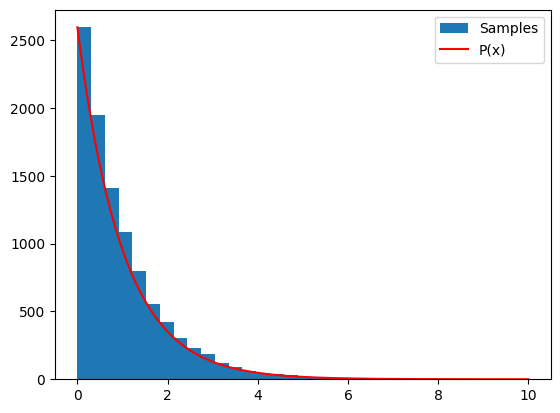

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Setup Finished")
# Rejection Sampling testing
P = lambda x: np.exp(-x)

# domain limits
xmin = 0 # the lower limit of our domain
xmax = 10 # the upper limit of our domain

# range limit (supremum) for y
ymax = 1
#you might have to do an optimization to find this.

N = 10000 # the total of samples we wish to generate
accepted = 0 # the number of accepted samples
samples = np.zeros(N)
count = 0 # the total count of proposals

# generation loop
while (accepted < N):
    
    # pick a uniform number on [xmin, xmax) (e.g. 0...10)
    x = np.random.uniform(xmin, xmax)
    
    # pick a uniform number on [0, ymax)
    y = np.random.uniform(0,ymax)
    
    # Do the accept/reject comparison
    if y < P(x):
        samples[accepted] = x
        accepted += 1
    
    count +=1
    
print("Count",count, "Accepted", accepted)

# get the histogram info
hinfo = np.histogram(samples,30)

# plot the histogram
plt.hist(samples,bins=30, label=u'Samples')

# plot our (normalized) function
xvals=np.linspace(xmin, xmax, 1000)
plt.plot(xvals, hinfo[0][0]*P(xvals), 'r', label=u'P(x)')

# turn on the legend
plt.legend()

Count 24103 Accepted 10000


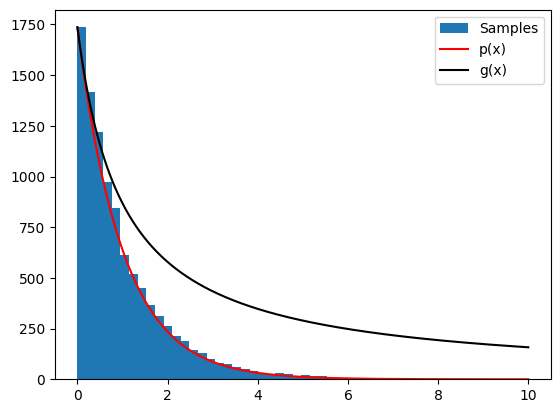

In [4]:
p = lambda x: np.exp(-x)  # our distribution
g = lambda x: 1/(x+1)  # our proposal pdf (we're thus choosing M to be 1)
invCDFg = lambda x: np.log(x +1) # generates our proposal using inverse sampling

# domain limits
xmin = 0 # the lower limit of our domain
xmax = 10 # the upper limit of our domain

# range limits for inverse sampling
umin = invCDFg(xmin)
umax = invCDFg(xmax)

N = 10000 # the total of samples we wish to generate
accepted = 0 # the number of accepted samples
samples = np.zeros(N)
count = 0 # the total count of proposals

# generation loop
while (accepted < N):
    
    # Sample from g using inverse sampling
    u = np.random.uniform(umin, umax)
    xproposal = np.exp(u) - 1
    
    # pick a uniform number on [0, 1)
    y = np.random.uniform(0,1)
    
    # Do the accept/reject comparison
    if y < p(xproposal)/g(xproposal):
        samples[accepted] = xproposal
        accepted += 1
    
    count +=1
    
print("Count", count, "Accepted", accepted)

# get the histogram info
hinfo = np.histogram(samples,50)

# plot the histogram
plt.hist(samples,bins=50, label=u'Samples');

# plot our (normalized) function
xvals=np.linspace(xmin, xmax, 1000)
plt.plot(xvals, hinfo[0][0]*p(xvals), 'r', label=u'p(x)')
plt.plot(xvals, hinfo[0][0]*g(xvals), 'k', label=u'g(x)')



# turn on the legend
plt.legend()

<Figure size 640x480 with 0 Axes>

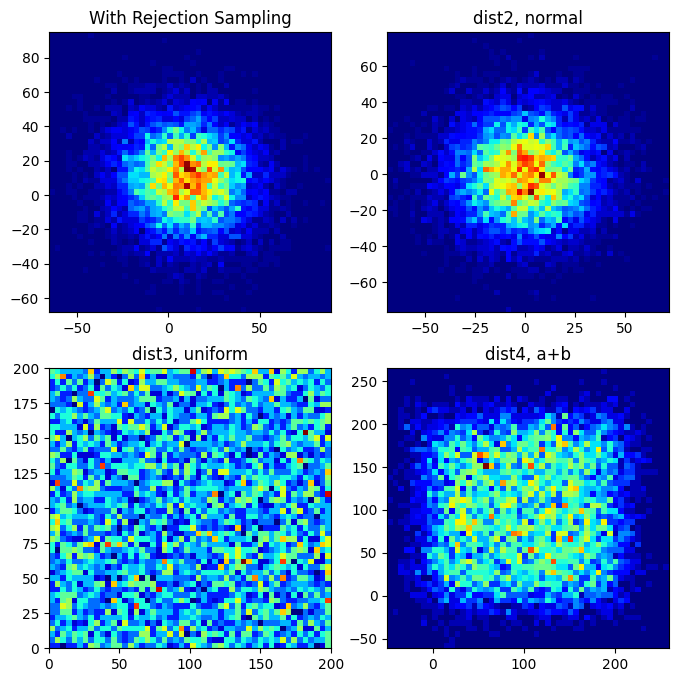

In [16]:
import numpy 
import math
import random
numbercoefff= 128*3
maxval = 200
sigma = 20
n = 2

def inner_product(arr1,arr2):
    sum = 0
    for i in range(arr1.__len__()):
        sum += arr1[i]*arr2[i]
    return sum
    
def l2_norm(arr1):
    arr1_sq = [item*item for item in arr1]
    s = sum(arr1_sq)
    return math.sqrt(s)

# for v
def dist1():
    return [random.randint(0,maxval) for _ in range(n)]

# for y
def dist2():
    return numpy.random.normal(0, sigma, n)

def rej_sampling(zvec,vvec,sigma):
    u = random.random()
    M = 5
    # print( (-2) * (inner_product(zvec,vvec)) + (l2_norm(vvec)**2))
    # print((2*sigma*sigma))
    exptarget= ((-2) * (inner_product(zvec,vvec)) + (l2_norm(vvec)**2)) / (2*sigma*sigma)
    # print ("exp:",exptarget)
    # print(math.exp(exptarget))
    if u > (1/M) * math.exp( exptarget):
        return 1
    else:
        return 0

def dist3():
    counter =0 
    while True:
        d1 = dist1()
        d2 = dist2()
        if rej_sampling(d1+d2,d1,sigma)==0:
            return [d1[i]+d2[i] for i in range(n)]
            
def dist4():
    d1 = dist1()
    d2 = dist2()
    return [d1[i]+d2[i] for i in range(n)]

# plot our (normalized) function
xvals=np.linspace(xmin, xmax, 1000)

N=10000
samplesX = np.zeros(N)
samplesY = np.zeros(N)
for i in range(N):
    (x,y) = dist3()
    samplesX[i] = x
    samplesY[i] = y
    
cmp_samplesX = np.zeros(N)
cmp_samplesY = np.zeros(N)
for i in range(N):
    (x,y) = dist2()
    cmp_samplesX[i] = x
    cmp_samplesY[i] = y
    
    
cmp1_samplesX = np.zeros(N)
cmp1_samplesY = np.zeros(N)
for i in range(N):
    (x,y) = dist1()
    cmp1_samplesX[i] = x
    cmp1_samplesY[i] = y
    
cmp2_samplesX = np.zeros(N)
cmp2_samplesY = np.zeros(N)
for i in range(N):
    (x,y) = dist4()
    cmp2_samplesX[i] = x
    cmp2_samplesY[i] = y


plt.clf()
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8,8))
# Big bins
axs[0,0].hist2d(samplesX, samplesY, bins=(50,50), cmap=plt.cm.jet)
axs[0, 0].set_title('With Rejection Sampling')
 
# Small bins
axs[0,1].hist2d(cmp_samplesX, cmp_samplesY, bins=(50, 50), cmap=plt.cm.jet)
axs[0, 1].set_title('dist2, normal')
 
# If you do not set the same values for X and Y, the bins won't be a square!
axs[1,0].hist2d(cmp1_samplesX, cmp1_samplesY, bins=(50, 50), cmap=plt.cm.jet)
axs[1, 0].set_title('dist3, uniform')

# If you do not set the same values for X and Y, the bins won't be a square!
axs[1,1].hist2d(cmp2_samplesX, cmp2_samplesY, bins=(50, 50), cmap=plt.cm.jet)
axs[1, 1].set_title('dist4, a+b')

plt.show()

In [50]:
from scipy.spatial import distance

import numpy as np

# This seem to require array to have probabiltiy distribution instead of the sample from the distribution...
arr1= [random.uniform(1,100) for i in range(10000)]
arr2 =  [random.uniform(1,100) for i in range(10000)]
print(distance.jensenshannon(arr1,arr2))

arr1= [random.gauss(1,40) for i in range(1000)]
arr2 =  [random.gauss(1,40) for i in range(1000)]
print(distance.jensenshannon(arr1,arr2))

0.3078892174013799
inf


In [20]:
import math
import random
def montgomery_parameter(n_mod):
    n_bits = n_mod.bit_length()
    
    r_mod = None
    
    for i in range(1, 128-n_bits):
        try_rmod = 2**(n_bits+i)
        if (math.gcd(try_rmod, n_mod) == 1):
            r_mod = try_rmod
            break
        
    r_mod_inv = pow(r_mod,-1,n_mod)
    
    assert (((r_mod*r_mod_inv)-1)/n_mod).is_integer()
    n_mod_prime = ((r_mod*r_mod_inv)-1)//n_mod
    
    print(f"r_mod:{r_mod}, RMOD_BIT_SHIFT = {r_mod.bit_length()-1}, RMOD_MODULO_MASK = {r_mod-1}, n_mod_prime: {n_mod_prime}",)
    MODR_BIT_SHIFT = r_mod.bit_length()-1
    MODR_MASK = r_mod -1
    
    def reduce(x, r_mod, n_mod, n_mod_prime):
        assert (x <= (n_mod*r_mod-1))
        temp_q = ((x&MODR_MASK) * n_mod_prime) & MODR_MASK # r_mod should be implemented with bit masking with (r_mod-1) because r_mod is of the form 0b1000...
        assert ( ((x) + (temp_q*n_mod)) / r_mod).is_integer()
        a = ((x) + (temp_q*n_mod)) >> MODR_BIT_SHIFT #right bit shift by b where 2**b = r_mod
        if a >= n_mod:
            a = a-n_mod
        assert 0 <= a < n_mod
        return a
        
    num1 = random.randint(0, n_mod)
    num2 = random.randint(0, n_mod)
    num1R = (num1 * r_mod) % n_mod
    num2R = (num2 * r_mod) % n_mod
    
    num12RR = num1R * num2R
    num12R = reduce(num12RR, r_mod, n_mod,n_mod_prime)
    
    assert num12R == ( (num1*num2*r_mod) % n_mod)
    num12 = reduce(num12R, r_mod, n_mod,n_mod_prime)
    
    assert (num12 == ((num1*num2) % n_mod))
    
    assert 2**(r_mod.bit_length()-1) == r_mod
    # Test
    
montgomery_parameter(5732819311601719681)

r_mod:18446744073709551616, RMOD_BIT_SHIFT = 64, RMOD_MODULO_MASK = 18446744073709551615, n_mod_prime: 2911130487753464191


In [7]:
"10010011001100001101110010000001111100010001010100010100101011".__len__()

62

In [8]:
print((-6981105450506112256) % 2**64)
print(5732819311601719681-1+5732819311601719681-1)

print( (5732819311601719681-1+5732819311601719681-1) % 5732819311601719681)
print(-1248286138904392575 % 2**64)

11465638623203439360
11465638623203439360
5732819311601719679
17198457934805159041


In [9]:
bin(-1 % 2**64)[2:].__len__()

64

In [10]:
import hashlib
import functools

result_ntt = [1865432272857165792, 1, 3867387038744553891, 1, 3081264418323944535, 1, 2651554893277775148, 1, 516284183328672273, 1, 5216535128273047410, 1, 58627841374780718, 1, 5674191470226938965, 1, 2329502181836590025, 1, 3403317129765129658, 1, 3474748950470412314, 1, 2258070361131307369, 1, 4732242602738261750, 1, 1000576708863457933, 1, 4900793769766148186, 1, 832025541835571497, 1, 793371259882520057, 1, 4939448051719199626, 1, 4975003683969001609, 1, 757815627632718074, 1, 868527363545096247, 1, 4864291948056623436, 1, 4827236915693016083, 1, 905582395908703600, 1, 3797041541020420934, 1, 1935777770581298749, 1, 1537257728251637321, 1, 4195561583350082362, 1, 4649223082417047011, 1, 1083596229184672672, 1, 2209059537366756535, 1, 3523759774234963148, 1, 3003706446654461458, 1, 2729112864947258225, 1, 1310915837785077849, 1, 4421903473816641834, 1, 5408614457072635463, 1, 324204854529084220, 1, 4711140135757253817, 1, 1021679175844465866, 1, 4960658434478852464, 1, 772160877122867219, 1, 2661216321618014339, 1, 3071602989983705344, 1, 394472531573903252, 1, 5338346780027816431, 1, 4778390649975217591, 1, 954428661626502092, 1, 2043257941870343014, 1, 3689561369731376669, 1, 595262870210055915, 1, 5137556441391663768, 1, 3499368174953980185, 1, 2233451136647739498, 1, 5707055816420717883, 1, 25763495181001800, 1, 2496433315255045688, 1, 3236385996346673995, 1, 2764105190024138488, 1, 2968714121577581195, 1, 1562216716643964105, 1, 4170602594957755578, 1, 3326795404307850968, 1, 2406023907293868715, 1]

hashlib.sha256(functools.reduce(lambda x,y: x+str(y), result_ntt, "").encode("utf-8")).digest().hex()

'd208431ffc6e1b7996f01fdd498cf1e41aac847e65cc9d2ba905c7af9060b65b'

In [11]:
import numpy as np
a = np.array([1,2,3,4,5,6,7,8,9])
b = np.array([9,8,7,6,5,4,3,2,1])
print(np.inner(a,b))

c = np.array([8,8,8,8,8,8,8,8,8])
print(np.inner(c,b))

165
360


In [12]:
a = np.array([[1, 2,3,4,5,6,7,8,9],
              [8,8,8,8,8,8,8,8,8],
             [5,5,5,5,5,5,5,5,5]])
b = np.array([[9,1],[8,2],[7,3],[6,4],[5,5],[4,4],[3,3],[2,2],[1,1]])

np.matmul(a,b)

array([[165, 125],
       [360, 200],
       [225, 125]])

In [13]:
q = 5
minusq = int(-((q-1)/2))
posq = -minusq
for i in range(-2,2+1):
    # print(i)
    print(i ,i%q)
    
print()

for i in range(q):
    # print(i)
    if (i-int((q-1)/2) > 0) == True:
        print(i,i-q)
    else:
        print(i)

-2 3
-1 4
0 0
1 1
2 2

0
1
2
3 -2
4 -1


In [14]:
q= 5732819311601719681
minusq = int(-((q-1)/2))
posq = -minusq

i = 4859043202474992143
if (i-int((q-1)/2) > 0) == True:
    print(i,i-q)
else:
    print(i)
    
(i-q)%q

4859043202474992143 -873776109126727538


4859043202474992143

In [15]:
a = [i*i for i in range(128)]
print(a)

import numpy as np
from numpy import linalg as LA
ap = np.array(a)
print(LA.norm(ap, ord=1))
print(LA.norm(ap, ord=2))
LA.norm(ap, ord=np.inf)

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81, 100, 121, 144, 169, 196, 225, 256, 289, 324, 361, 400, 441, 484, 529, 576, 625, 676, 729, 784, 841, 900, 961, 1024, 1089, 1156, 1225, 1296, 1369, 1444, 1521, 1600, 1681, 1764, 1849, 1936, 2025, 2116, 2209, 2304, 2401, 2500, 2601, 2704, 2809, 2916, 3025, 3136, 3249, 3364, 3481, 3600, 3721, 3844, 3969, 4096, 4225, 4356, 4489, 4624, 4761, 4900, 5041, 5184, 5329, 5476, 5625, 5776, 5929, 6084, 6241, 6400, 6561, 6724, 6889, 7056, 7225, 7396, 7569, 7744, 7921, 8100, 8281, 8464, 8649, 8836, 9025, 9216, 9409, 9604, 9801, 10000, 10201, 10404, 10609, 10816, 11025, 11236, 11449, 11664, 11881, 12100, 12321, 12544, 12769, 12996, 13225, 13456, 13689, 13924, 14161, 14400, 14641, 14884, 15129, 15376, 15625, 15876, 16129]
690880.0
82087.93450928097


np.float64(16129.0)

In [1]:
#Assign Beta-bit precision, Compute CDT [i] := [2^B Pr[c<=i | c <-sigma Z]], for i in [-t+1 ... t-1] with the snakkest t such that Pr[|c| >= t | c <- sigma Z] < 2^-beta.
# To sample: sample u <- Z/2^beta Z, return z s.t. CDT[z] <= u < CDT[z+1]  
# We only do positive sample. Then uses sign for flipping due to the symmetric nature of discrete gaussian distribution.

import struct
import math
import os
import bisect
from typing import List, Tuple

def build_cdt_sigma(sigma: float,
                    tail_eps: float = 2**-64,
                    scale_bits: int = 64) -> Tuple[List[int], int]:
    """
    Build a CDT for the nonnegative discrete Gaussian with mean=0, std=sigma.
    Returns:
      cdt: nondecreasing list of scaled cumulative masses for k=0..k_max (|X| values)
      k_max: the maximum |X| index covered by the table
    """
    # Choose a conservative cutoff: 12*sigma covers tail well below 2^-64 for large sigma
    k_max = int(math.ceil(6.0 * sigma))

    # Unnormalized weights for k >= 0 (folded distribution)
    # p_fold(k) = exp(-k^2/(2*sigma^2)) for k>=1; p_fold(0) = 1 (same as formula)
    weights = [1.0]
    two_sigma2 = 2.0 * sigma * sigma
    for k in range(1, k_max + 1):
        weights.append(math.exp(-(k * k) / two_sigma2))

    # Normalize folded distribution to represent Pr(|X|=k)
    total = sum(weights)
    probs = [w / total for w in weights]

    # Optional: check tail is negligible; if not, extend (shouldn’t trigger with 12*sigma)
    tail_mass = 0.0  # because we cut exactly at k_max
    assert tail_mass <= tail_eps, "Tail too large; increase k_max"

    # Build integer CDT scaled to [0, 2^scale_bits)
    scale = (1 << scale_bits) - 1
    cdt = []
    acc = 0.0
    run = 0
    for p in probs:
        acc += p
        # avoid rounding causing non-monotone steps by max with previous
        run = max(run, int(round(acc * scale)))
        run = min (run,  (1 << scale_bits) - 1)
        cdt.append(run)
    # Ensure the last element reaches the full scale
    cdt[-1] = (1 << scale_bits) - 1
    return cdt, k_max

def sample_discrete_gaussian_cdt(cdt: List[int], k_max: int) -> int:
    """
    Sample from D_{Z, sigma, 0} using a folded CDT (for |X|) and a random sign.
    Requires Python 3.9+ for os.urandom-based 64-bit uniform.
    """
    # 64-bit uniform in [0, 2^64-1]
    u = int.from_bytes(os.urandom(8), "big")
    # binary search in CDT for |X|
    idx = bisect.bisect_left(cdt, u)
    abs_x = idx  # because cdt[k] corresponds to |X| = k
    # random sign (but zero has no sign)
    if abs_x == 0:
        return 0
    sign_bit = (int.from_bytes(os.urandom(1), "big") & 1)
    return abs_x if sign_bit == 0 else -abs_x

# ---- Example usage for sigma=27000 ----
sigma =7237284
# sigma = 3618643
# sigma = 384912
# 384912
cdt, kmax = build_cdt_sigma(sigma)
print(kmax)
# print(cdt[:10])
print(f"CDT length: {len(cdt)} (k_max={kmax})")
# draw a few samples

# print(cdt[21711836:])
with open("cdt.bin", "wb") as f:
    for index, cdt_score in enumerate(cdt):
        assert f.write(struct.pack("<Q", cdt_score)) == 8

# Time constraining operation, binary search
import time
timenow = time.time()
# 10 ms allow us to sample 10 polynomials
for _ in range(2560):
    print(sample_discrete_gaussian_cdt(cdt, kmax))
(time.time() -timenow)

43423704
CDT length: 43423705 (k_max=43423704)
13944952
-18349886
130883
194630
6042565
-1333662
-2005542
9861447
6241015
2195315
806918
2596499
-2848503
-4771706
-1798375
9181575
1232801
6029565
-6257246
-9717406
-6477612
5640444
-1121266
3260529
66818
2053673
425554
14061353
-1672016
4453454
-543242
-7846635
-1346835
394619
-9956577
-3552744
-3099732
-12343012
-6135533
-7332895
8925410
-4672685
14824290
-4493552
-4525371
-4910413
-7974659
6363448
3766417
7390855
-4379060
5705734
5346297
-7350585
-2170612
13693996
-1116214
8234196
2476167
-10747529
6026382
6503791
-4154141
-188983
4039478
2217012
8898807
-9324091
-5519878
3206776
3996607
-2477831
-11943301
3320347
-3460360
-3163751
6900255
-15405038
-952225
-4851689
-6048895
7949765
9142944
-11684507
1909197
10183863
-9563351
697403
589867
-3647988
4931181
-5019970
2718346
-12096888
5108449
-5267821
-7579517
2130330
-6081014
2411464
4706619
777383
17610446
4618212
-12214919
-1359585
58866
6212498
-7289225
791714
-6879474
7076414
-3699

0.01663994789123535

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def sample_discrete_gaussian_cdt(cdt, k_max, n):
    samples = np.empty(n, dtype=np.int64)
    for i in range(n):
        u = int.from_bytes(os.urandom(8), "big")
        idx = bisect.bisect_left(cdt, u)
        if idx == 0:
            x = 0
        else:
            # random sign
            sign_bit = (int.from_bytes(os.urandom(1), "big") & 1)
            x = idx if sign_bit == 0 else -idx
        samples[i] = x
    return samples

# Parameters
# sigma = 3618643

# Build CDT and draw samples
cdt, kmax = build_cdt_sigma(sigma)
n_samples = 1000000
samples = sample_discrete_gaussian_cdt(cdt, kmax, n_samples)

Sample mean ≈ -670.45, sample std ≈ 3617826.50 (target σ = 3618643)
-0.02256362598711211


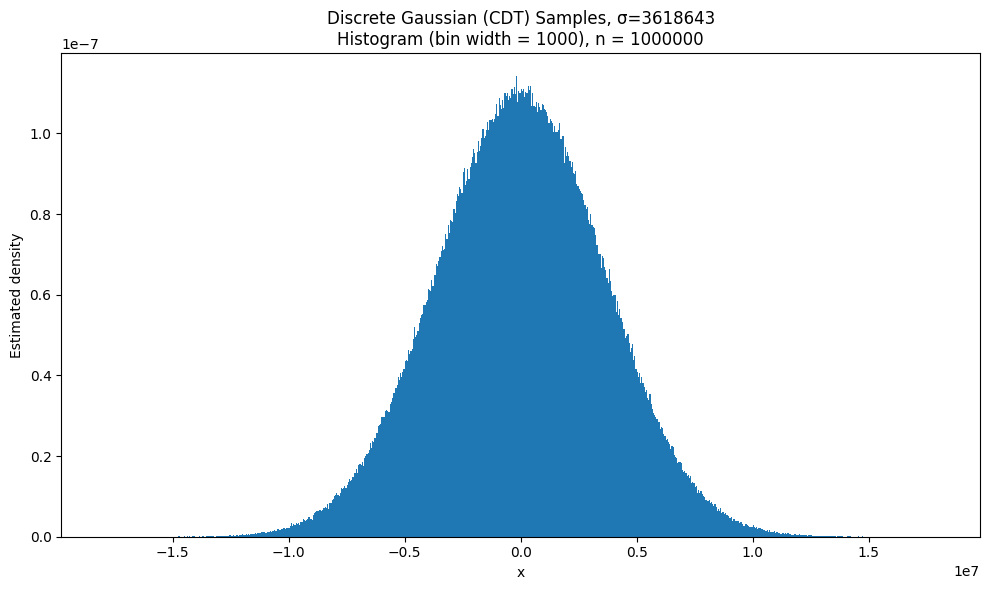

In [18]:
# Basic stats
mean = float(np.mean(samples))
std = float(np.std(samples, ddof=1))

# Plot histogram (single chart, no styles/colors set)
plt.figure(figsize=(10,6))
# Use wider bins for readability given huge sigma
bin_width = 50000
limit = 3_000_000*6
# limit = 150_000
bins = np.arange(-limit, limit + bin_width, bin_width)
plt.hist(samples, bins=bins, density=True)
plt.title("Discrete Gaussian (CDT) Samples, σ={}\nHistogram (bin width = 1000), n = {}".format(sigma, n_samples))
plt.xlabel("x")
plt.ylabel("Estimated density")
plt.tight_layout()

# Print stats so they appear alongside the plot
print(f"Sample mean ≈ {mean:.2f}, sample std ≈ {std:.2f} (target σ = {sigma:.0f})")
print((std-sigma)/sigma * 100)

In [2]:
import math
math.log2(337867237148089856)

58.229234072803735